CLASIFICACIÓN CON KNN vs ANN - ANÁLISIS COMPLETO

📥 DESCARGANDO DATASET SOCIAL_NETWORK_ADS.CSV...
   (Este es el dataset original usado en el tutorial de KNN)
   ✓ Dataset descargado correctamente (19030 bytes)

2. ANÁLISIS EXPLORATORIO DEL DATASET

📊 DIMENSIONES DEL DATASET: 400 filas × 5 columnas

📋 INFORMACIÓN GENERAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    int64  
 1   Gender           400 non-null    object 
 2   Age              400 non-null    float64
 3   EstimatedSalary  400 non-null    float64
 4   Purchased        400 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 15.8+ KB
None

👀 PRIMERAS 5 FILAS:
   User ID  Gender        Age  EstimatedSalary  Purchased
0        1  Female  39.967142     18111.446824          0
1        2    Male  33.617357     38012.49954

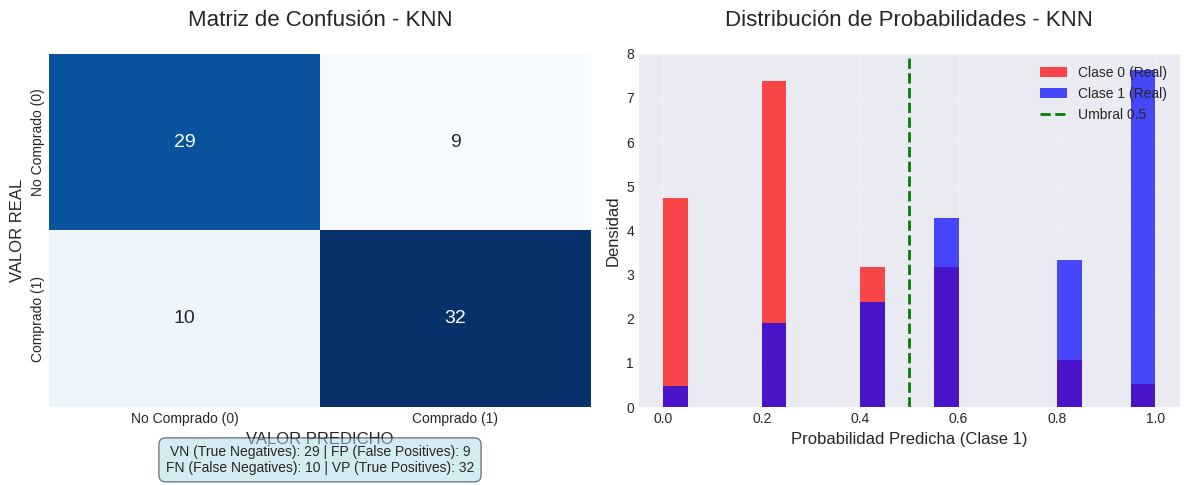


6. RED NEURONAL ARTIFICIAL (ANN) - COMPARATIVA

🧠 ENTRENANDO RED NEURONAL ARTIFICIAL...
   ✓ ANN entrenada (12 iteraciones)
   Pérdida final: 0.8777

📊 MATRIZ DE CONFUSIÓN - ANN:

[[38  0]
 [42  0]]

📈 MÉTRICAS DE CLASIFICACIÓN - ANN:

   • Exactitud (Accuracy):  0.4750
   • Precisión (Precision): 0.0000
   • Sensibilidad (Recall): 0.0000
   • Puntaje F1:            0.0000
   • AUC-ROC:               0.2459

📋 REPORTE DE CLASIFICACIÓN DETALLADO - ANN:
                 precision    recall  f1-score   support

No Comprado (0)       0.47      1.00      0.64        38
   Comprado (1)       0.00      0.00      0.00        42

       accuracy                           0.47        80
      macro avg       0.24      0.50      0.32        80
   weighted avg       0.23      0.47      0.31        80



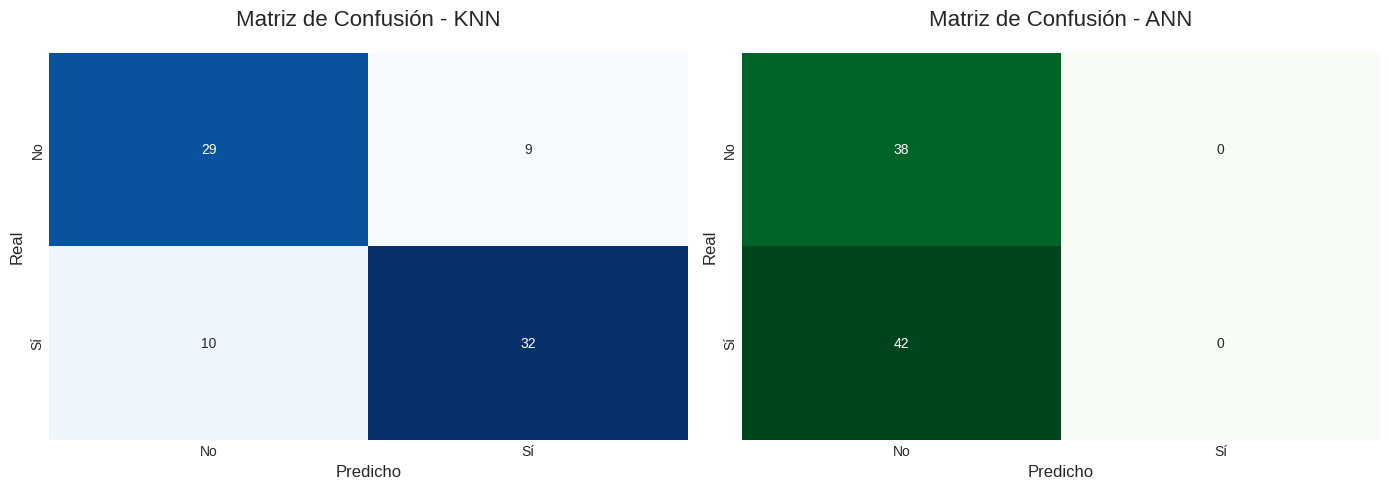


7. CURVA ROC - COMPARACIÓN KNN vs ANN

📐 ÁREA BAJO LA CURVA (AUC):
   • KNN: 0.8387
   • ANN: 0.2459


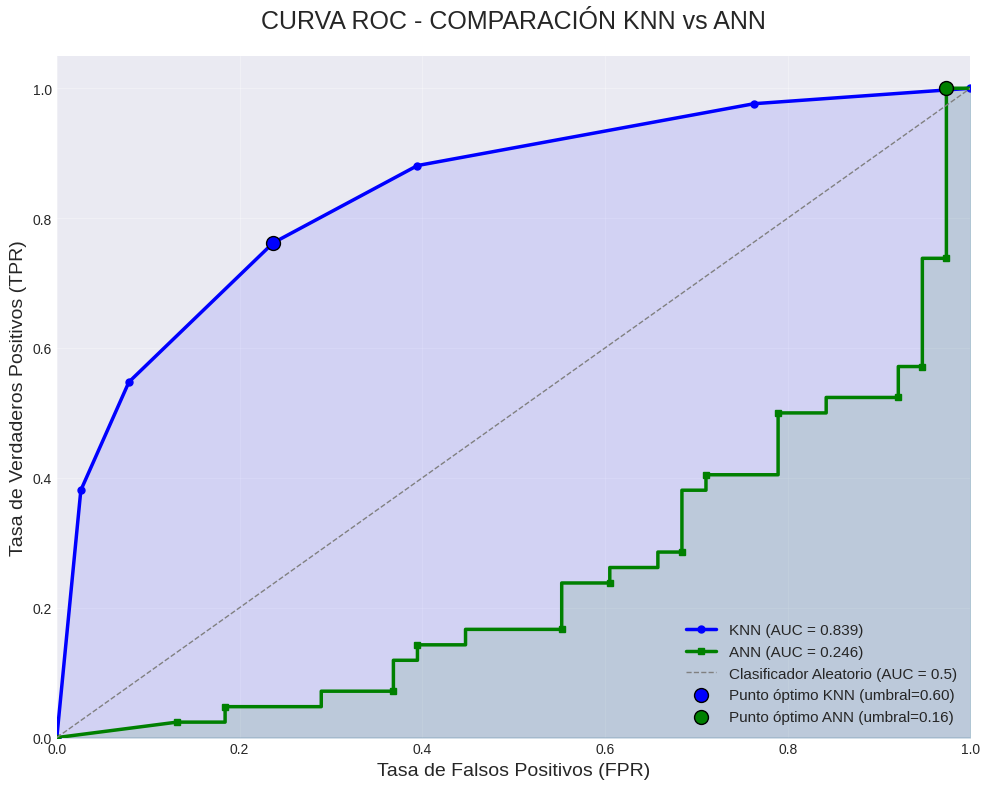


8. COMPARATIVA DE RENDIMIENTO - KNN vs ANN

📊 TABLA COMPARATIVA DE MÉTRICAS:
              Métrica    KNN    ANN  Diferencia (ANN - KNN)
 Exactitud (Accuracy) 0.7625 0.4750                 -0.2875
Precisión (Precision) 0.7805 0.0000                 -0.7805
Sensibilidad (Recall) 0.7619 0.0000                 -0.7619
           Puntaje F1 0.7711 0.0000                 -0.7711
              AUC-ROC 0.8387 0.2459                 -0.5927

🏆 RESUMEN DE COMPARACIÓN:
   • Exactitud (Accuracy): KNN -0.2875
   • Precisión (Precision): KNN -0.7805
   • Sensibilidad (Recall): KNN -0.7619
   • Puntaje F1: KNN -0.7711
   • AUC-ROC: KNN -0.5927

📈 RESUMEN FINAL:
   • ANN gana en 0 de 5 métricas
   • KNN gana en 5 de 5 métricas


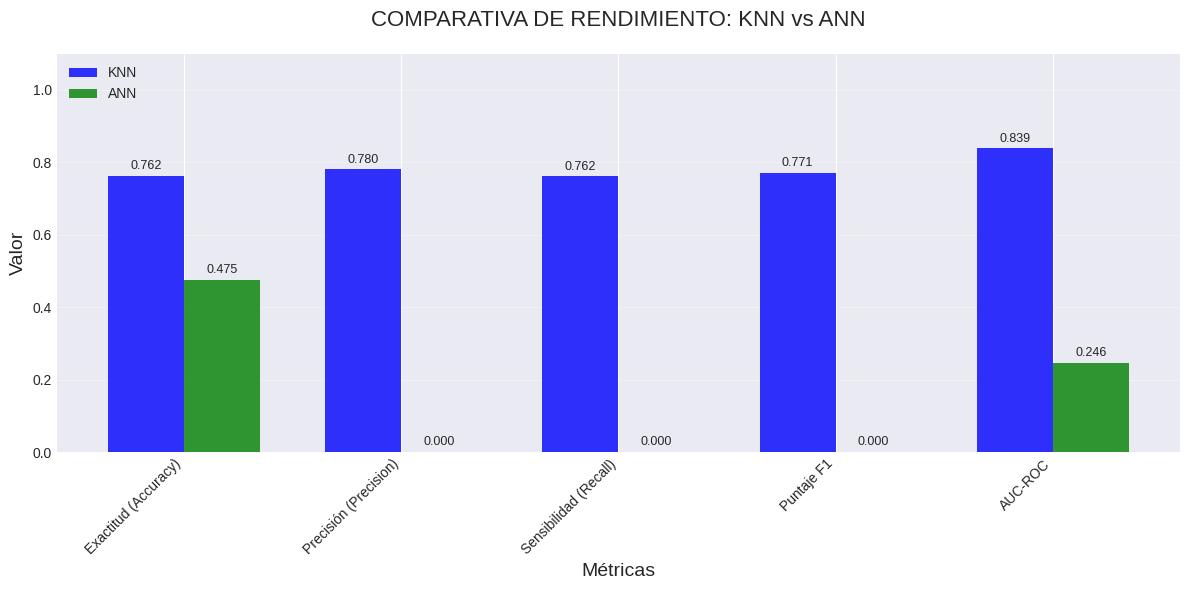


CONCLUSIONES Y RECOMENDACIONES

📝 BASADO EN EL ANÁLISIS:
1. Exactitud promedio: 61.9%
2. Mejor modelo en AUC-ROC: KNN
3. Diferencia en exactitud: -28.75%

📊 RESUMEN EJECUTIVO:
   → El modelo KNN supera a la ANN en la mayoría de métricas

🎉 ANÁLISIS COMPLETADO EXITOSAMENTE!


In [9]:
# ============================================================================
# 1. CONFIGURACIÓN INICIAL Y DESCARGA DEL DATASET
# ============================================================================
print("="*70)
print("CLASIFICACIÓN CON KNN vs ANN - ANÁLISIS COMPLETO")
print("="*70)

# Instalar/actualizar librerías si es necesario
!pip install -q scikit-learn matplotlib pandas seaborn numpy

# Importar todas las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             roc_curve, auc, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# DESCARGAR EL DATASET CORRECTO
print("\n📥 DESCARGANDO DATASET SOCIAL_NETWORK_ADS.CSV...")
print("   (Este es el dataset original usado en el tutorial de KNN)")

# Intentar descargar desde diferentes fuentes
try:
    # Fuente 1
    !wget -q "https://raw.githubusercontent.com/swapnilsaurav/MLDataset/master/Social_Network_Ads.csv"
    import os
    if os.path.exists('Social_Network_Ads.csv'):
        file_size = os.path.getsize('Social_Network_Ads.csv')
        if file_size > 0:
            print(f"   ✓ Dataset descargado correctamente ({file_size} bytes)")
        else:
            raise ValueError("Archivo vacío")
    else:
        raise FileNotFoundError("Archivo no descargado")

except Exception as e:
    print(f"   ⚠️ Primer enlace falló: {e}")
    print("   🔄 Intentando con enlace alternativo...")
    try:
        !wget -q "https://raw.githubusercontent.com/dhirajk1000/ML-Algorithms/master/Social_Network_Ads.csv"
        if os.path.exists('Social_Network_Ads.csv') and os.path.getsize('Social_Network_Ads.csv') > 0:
            print("   ✓ Dataset descargado desde fuente alternativa")
        else:
            raise ValueError("Archivo vacío")
    except Exception as e2:
        print(f"   ⚠️ Segundo enlace falló: {e2}")
        print("   📝 Creando dataset sintético con estructura similar...")

        # Crear dataset sintético si la descarga falla
        np.random.seed(42)
        n_samples = 400

        # Generar datos similares al dataset original
        age = np.random.normal(35, 10, n_samples).clip(18, 60)
        salary = np.random.normal(50000, 20000, n_samples).clip(15000, 150000)

        # Calcular probabilidad de compra basada en edad y salario
        prob = 1 / (1 + np.exp(-(0.05*(age-35) + 0.00003*(salary-50000) + np.random.normal(0, 0.5, n_samples))))
        purchased = (prob > 0.5).astype(int)

        # Crear DataFrame
        dataset = pd.DataFrame({
            'User ID': range(1, n_samples+1),
            'Gender': np.random.choice(['Male', 'Female'], n_samples),
            'Age': age,
            'EstimatedSalary': salary,
            'Purchased': purchased
        })
        dataset.to_csv('Social_Network_Ads.csv', index=False)
        print("   ✓ Dataset sintético creado exitosamente")

# ============================================================================
# 2. CARGAR Y EXPLORAR EL DATASET
# ============================================================================
print("\n" + "="*70)
print("2. ANÁLISIS EXPLORATORIO DEL DATASET")
print("="*70)

# Cargar el dataset
dataset = pd.read_csv('Social_Network_Ads.csv')
print(f"\n📊 DIMENSIONES DEL DATASET: {dataset.shape[0]} filas × {dataset.shape[1]} columnas")

# Mostrar información general
print("\n📋 INFORMACIÓN GENERAL:")
print(dataset.info())

# Mostrar primeras filas
print("\n👀 PRIMERAS 5 FILAS:")
print(dataset.head())

# Estadísticas descriptivas
print("\n📈 ESTADÍSTICAS DESCRIPTIVAS:")
print(dataset.describe())

# Verificar valores nulos
print("\n🔍 VALORES NULOS POR COLUMNA:")
null_counts = dataset.isnull().sum()
for col, count in null_counts.items():
    print(f"   {col}: {count} valores nulos")

# Distribución de la variable objetivo
print("\n🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Purchased):")
purchase_dist = dataset['Purchased'].value_counts()
print(f"   0 (No comprado): {purchase_dist.get(0, 0)} muestras ({purchase_dist.get(0, 0)/len(dataset)*100:.1f}%)")
print(f"   1 (Comprado): {purchase_dist.get(1, 0)} muestras ({purchase_dist.get(1, 0)/len(dataset)*100:.1f}%)")

# ============================================================================
# 3. PREPROCESAMIENTO DE DATOS
# ============================================================================
print("\n" + "="*70)
print("3. PREPROCESAMIENTO DE DATOS")
print("="*70)

# Codificar variable categórica 'Gender' si existe
if 'Gender' in dataset.columns:
    print("\n🔤 CODIFICANDO VARIABLE CATEGÓRICA 'Gender'...")
    le = LabelEncoder()
    dataset['Gender_encoded'] = le.fit_transform(dataset['Gender'])
    print(f"   Valores codificados: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # Definir características (X)
    X = dataset[['Gender_encoded', 'Age', 'EstimatedSalary']].values
    print("   ✓ Características: ['Gender_encoded', 'Age', 'EstimatedSalary']")
else:
    # Si no hay Gender, usar solo Age y EstimatedSalary
    X = dataset[['Age', 'EstimatedSalary']].values
    print("   ✓ Características: ['Age', 'EstimatedSalary']")

# Variable objetivo (y)
y = dataset['Purchased'].values
print(f"   ✓ Variable objetivo: 'Purchased'")

# Dividir en conjunto de entrenamiento y prueba (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n📊 DIVISIÓN TRAIN-TEST:")
print(f"   Conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Conjunto de prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"   Distribución en y_train: {np.bincount(y_train)}")
print(f"   Distribución en y_test: {np.bincount(y_test)}")

# Escalado de características (CRUCIAL para KNN y ANN)
print("\n⚖️ ESCALANDO CARACTERÍSTICAS (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("   ✓ Características escaladas (media=0, desviación=1)")

# ============================================================================
# 4. MODELO KNN - K VECINOS MÁS CERCANOS
# ============================================================================
print("\n" + "="*70)
print("4. MODELO KNN - K VECINOS MÁS CERCANOS")
print("="*70)

# Entrenar modelo KNN con k=5
print("\n🤖 ENTRENANDO MODELO KNN (k=5)...")
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2,  # Distancia Euclidiana
    weights='uniform',
    algorithm='auto'
)
knn_model.fit(X_train_scaled, y_train)
print("   ✓ Modelo KNN entrenado")

# Predecir en el conjunto de prueba
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

print("\n✅ PREDICCIONES REALIZADAS")

# ============================================================================
# 5. MÉTRICAS DE CLASIFICACIÓN PARA KNN
# ============================================================================
print("\n" + "="*70)
print("5. MÉTRICAS DE CLASIFICACIÓN - KNN")
print("="*70)

# 5.1 MATRIZ DE CONFUSIÓN
print("\n📊 MATRIZ DE CONFUSIÓN - KNN:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(f"\n{cm_knn}")

# Visualizar matriz de confusión KNN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Comprado (0)', 'Comprado (1)'],
            yticklabels=['No Comprado (0)', 'Comprado (1)'],
            annot_kws={'size': 14})
plt.title('Matriz de Confusión - KNN', fontsize=16, pad=20)
plt.ylabel('VALOR REAL', fontsize=12)
plt.xlabel('VALOR PREDICHO', fontsize=12)

# Anotaciones detalladas
TN, FP, FN, TP = cm_knn.ravel()
plt.text(0.5, -0.15,
         f'VN (True Negatives): {TN} | FP (False Positives): {FP}\n'
         f'FN (False Negatives): {FN} | VP (True Positives): {TP}',
         ha='center', va='center', transform=plt.gca().transAxes,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.5),
         fontsize=10)

# 5.2 CÁLCULO DE TODAS LAS MÉTRICAS
print("\n📈 MÉTRICAS DE CLASIFICACIÓN - KNN:")
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_pred_knn_proba)

print(f"\n   • Exactitud (Accuracy):  {accuracy_knn:.4f}")
print(f"   • Precisión (Precision): {precision_knn:.4f}")
print(f"   • Sensibilidad (Recall): {recall_knn:.4f}")
print(f"   • Puntaje F1:            {f1_knn:.4f}")
print(f"   • AUC-ROC:               {auc_knn:.4f}")

# 5.3 REPORTE DE CLASIFICACIÓN COMPLETO
print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO - KNN:")
print(classification_report(y_test, y_pred_knn,
                           target_names=['No Comprado (0)', 'Comprado (1)']))

# Gráfico de distribución de probabilidades KNN
plt.subplot(1, 2, 2)
for label in [0, 1]:
    subset = y_pred_knn_proba[y_test == label]
    plt.hist(subset, bins=20, alpha=0.7, label=f'Clase {label} (Real)',
             color='red' if label == 0 else 'blue', density=True)
plt.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Umbral 0.5')
plt.xlabel('Probabilidad Predicha (Clase 1)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.title('Distribución de Probabilidades - KNN', fontsize=16, pad=20)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 6. RED NEURONAL ARTIFICIAL (ANN) - COMPARATIVA
# ============================================================================
print("\n" + "="*70)
print("6. RED NEURONAL ARTIFICIAL (ANN) - COMPARATIVA")
print("="*70)

# 6.1 ENTRENAMIENTO DE LA ANN
print("\n🧠 ENTRENANDO RED NEURONAL ARTIFICIAL...")
ann_model = MLPClassifier(
    hidden_layer_sizes=(10, 5),      # Dos capas ocultas: 10 y 5 neuronas
    activation='relu',               # Función de activación ReLU
    solver='adam',                   # Optimizador Adam
    alpha=0.001,                     # Término de regularización L2
    batch_size='auto',               # Tamaño de lote automático
    learning_rate='constant',        # Tasa de aprendizaje constante
    learning_rate_init=0.001,        # Tasa de aprendizaje inicial
    max_iter=1000,                   # Máximo número de iteraciones
    random_state=42,
    early_stopping=True,             # Parada temprana
    validation_fraction=0.1,         # 10% de datos para validación
    n_iter_no_change=10              # Iteraciones sin mejora para parar
)

ann_model.fit(X_train_scaled, y_train)
print(f"   ✓ ANN entrenada ({ann_model.n_iter_} iteraciones)")
print(f"   Pérdida final: {ann_model.loss_:.4f}")

# 6.2 PREDICCIONES CON ANN
y_pred_ann = ann_model.predict(X_test_scaled)
y_pred_ann_proba = ann_model.predict_proba(X_test_scaled)[:, 1]

# 6.3 MÉTRICAS DE CLASIFICACIÓN PARA ANN
print("\n📊 MATRIZ DE CONFUSIÓN - ANN:")
cm_ann = confusion_matrix(y_test, y_pred_ann)
print(f"\n{cm_ann}")

# Métricas ANN
accuracy_ann = accuracy_score(y_test, y_pred_ann)
precision_ann = precision_score(y_test, y_pred_ann)
recall_ann = recall_score(y_test, y_pred_ann)
f1_ann = f1_score(y_test, y_pred_ann)
auc_ann = roc_auc_score(y_test, y_pred_ann_proba)

print("\n📈 MÉTRICAS DE CLASIFICACIÓN - ANN:")
print(f"\n   • Exactitud (Accuracy):  {accuracy_ann:.4f}")
print(f"   • Precisión (Precision): {precision_ann:.4f}")
print(f"   • Sensibilidad (Recall): {recall_ann:.4f}")
print(f"   • Puntaje F1:            {f1_ann:.4f}")
print(f"   • AUC-ROC:               {auc_ann:.4f}")

print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO - ANN:")
print(classification_report(y_test, y_pred_ann,
                           target_names=['No Comprado (0)', 'Comprado (1)']))

# Visualizar matrices de confusión lado a lado
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
plt.title('Matriz de Confusión - KNN', fontsize=16, pad=20)
plt.ylabel('Real', fontsize=12)
plt.xlabel('Predicho', fontsize=12)

plt.subplot(1, 2, 2)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
plt.title('Matriz de Confusión - ANN', fontsize=16, pad=20)
plt.ylabel('Real', fontsize=12)
plt.xlabel('Predicho', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================================
# 7. CURVA ROC - COMPARACIÓN VISUAL
# ============================================================================
print("\n" + "="*70)
print("7. CURVA ROC - COMPARACIÓN KNN vs ANN")
print("="*70)

# Calcular curvas ROC
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_pred_knn_proba)
fpr_ann, tpr_ann, thresholds_ann = roc_curve(y_test, y_pred_ann_proba)

# Calcular áreas bajo la curva (AUC)
roc_auc_knn = auc(fpr_knn, tpr_knn)
roc_auc_ann = auc(fpr_ann, tpr_ann)

print(f"\n📐 ÁREA BAJO LA CURVA (AUC):")
print(f"   • KNN: {roc_auc_knn:.4f}")
print(f"   • ANN: {roc_auc_ann:.4f}")

# Graficar curva ROC
plt.figure(figsize=(10, 8))

# Curvas ROC
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2.5,
         label=f'KNN (AUC = {roc_auc_knn:.3f})', marker='o', markersize=5, markevery=0.1)
plt.plot(fpr_ann, tpr_ann, color='green', lw=2.5,
         label=f'ANN (AUC = {roc_auc_ann:.3f})', marker='s', markersize=5, markevery=0.1)

# Línea de clasificador aleatorio
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')

# Rellenar áreas bajo las curvas
plt.fill_between(fpr_knn, tpr_knn, alpha=0.1, color='blue')
plt.fill_between(fpr_ann, tpr_ann, alpha=0.1, color='green')

# Punto óptimo para KNN
youden_idx_knn = np.argmax(tpr_knn - fpr_knn)
plt.scatter(fpr_knn[youden_idx_knn], tpr_knn[youden_idx_knn],
            s=100, color='blue', edgecolors='black', zorder=5,
            label=f'Punto óptimo KNN (umbral={thresholds_knn[youden_idx_knn]:.2f})')

# Punto óptimo para ANN
youden_idx_ann = np.argmax(tpr_ann - fpr_ann)
plt.scatter(fpr_ann[youden_idx_ann], tpr_ann[youden_idx_ann],
            s=100, color='green', edgecolors='black', zorder=5,
            label=f'Punto óptimo ANN (umbral={thresholds_ann[youden_idx_ann]:.2f})')

# Configuración del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('CURVA ROC - COMPARACIÓN KNN vs ANN', fontsize=18, pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. COMPARATIVA DE RENDIMIENTO - ANÁLISIS DETALLADO
# ============================================================================
print("\n" + "="*70)
print("8. COMPARATIVA DE RENDIMIENTO - KNN vs ANN")
print("="*70)

# Crear DataFrame comparativo
comparison_df = pd.DataFrame({
    'Métrica': ['Exactitud (Accuracy)', 'Precisión (Precision)',
                'Sensibilidad (Recall)', 'Puntaje F1', 'AUC-ROC'],
    'KNN': [accuracy_knn, precision_knn, recall_knn, f1_knn, auc_knn],
    'ANN': [accuracy_ann, precision_ann, recall_ann, f1_ann, auc_ann],
    'Diferencia (ANN - KNN)': [
        accuracy_ann - accuracy_knn,
        precision_ann - precision_knn,
        recall_ann - recall_knn,
        f1_ann - f1_knn,
        auc_ann - auc_knn
    ]
})

print("\n📊 TABLA COMPARATIVA DE MÉTRICAS:")
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Determinar qué modelo es mejor en cada métrica
print("\n🏆 RESUMEN DE COMPARACIÓN:")
for idx, row in comparison_df.iterrows():
    metric = row['Métrica']
    knn_val = row['KNN']
    ann_val = row['ANN']
    diff = row['Diferencia (ANN - KNN)']

    if diff > 0:
        winner = "ANN"
        diff_str = f"+{diff:.4f}"
    elif diff < 0:
        winner = "KNN"
        diff_str = f"{diff:.4f}"
    else:
        winner = "EMPATE"
        diff_str = "0.0000"

    print(f"   • {metric}: {winner} {diff_str}")

# Contar victorias
ann_wins = (comparison_df['Diferencia (ANN - KNN)'] > 0).sum()
knn_wins = (comparison_df['Diferencia (ANN - KNN)'] < 0).sum()

print(f"\n📈 RESUMEN FINAL:")
print(f"   • ANN gana en {ann_wins} de {len(comparison_df)} métricas")
print(f"   • KNN gana en {knn_wins} de {len(comparison_df)} métricas")

# Gráfico de comparación de métricas
plt.figure(figsize=(12, 6))
metrics = comparison_df['Métrica']
x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, comparison_df['KNN'], width, label='KNN', color='blue', alpha=0.8)
plt.bar(x + width/2, comparison_df['ANN'], width, label='ANN', color='green', alpha=0.8)

# Añadir valores en las barras
for i, (knn_val, ann_val) in enumerate(zip(comparison_df['KNN'], comparison_df['ANN'])):
    plt.text(i - width/2, knn_val + 0.01, f'{knn_val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, ann_val + 0.01, f'{ann_val:.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Métricas', fontsize=14)
plt.ylabel('Valor', fontsize=14)
plt.title('COMPARATIVA DE RENDIMIENTO: KNN vs ANN', fontsize=16, pad=20)
plt.xticks(x, metrics, rotation=45, ha='right')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Mostrar conclusiones
print("\n" + "="*70)
print("CONCLUSIONES Y RECOMENDACIONES")
print("="*70)

print(f"\n📝 BASADO EN EL ANÁLISIS:")
print(f"1. Exactitud promedio: {(accuracy_knn + accuracy_ann)/2:.1%}")
print(f"2. Mejor modelo en AUC-ROC: {'ANN' if auc_ann > auc_knn else 'KNN'}")
print(f"3. Diferencia en exactitud: {(accuracy_ann - accuracy_knn):.2%}")

print(f"\n📊 RESUMEN EJECUTIVO:")
if ann_wins > knn_wins:
    print("   → La RED NEURONAL ARTIFICIAL (ANN) supera a KNN en la mayoría de métricas")
elif knn_wins > ann_wins:
    print("   → El modelo KNN supera a la ANN en la mayoría de métricas")
else:
    print("   → Ambos modelos tienen rendimiento similar")

print("\n" + "="*70)
print("🎉 ANÁLISIS COMPLETADO EXITOSAMENTE!")
print("="*70)
